# Title: Forward modeling of the HT-ATES site

**Research setting: hot water is injected into a shallow aquifer at the HT-ATES site in Delft. We investigate the use of a surface-to-borehole CSEM monitoring set-up for recovering the shape of the hot plume that develops.**

**This code is based on the EASYGO summer school exercises: https://github.com/emsig/easygo-training-em/blob/main/emg3d_ATES.ipynb**

We want to compare forward-modeling results between:
- Empymod: analytic solutions which can be used to evaluate if the grid is dense enough
- EASYGO-based simulations in Emg3d presented here
- Results found with Elfe3d by Paula
- Changes in parameters based on Emg3d work by Mahmoud on the deeper geothermal well (Eltayieb, 2023)

## In this version

DARTS plume is loaded in, from a heterogeneous subsurface model, with matching subsurface model

## To be updated
...

In [1]:
import emg3d
import empymod
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

plt.style.use('bmh')

# Comment this out on Google Colab
#%matplotlib widget

ModuleNotFoundError: No module named 'emg3d'

## Functions

In [2]:
#define interpolation functions
def find_distance2d(coord1, coord2):
    distance = (coord1[0]-coord2[0])**2+(coord1[1]-coord2[1])**2
    return distance
    #This is the distance squared but it should work the same

def interpolate2d(location, array):
    dis = []
    for i in np.arange(len(array)):
        dis.append(find_distance2d(location, array[i]))
    return np.argmin(dis)

## Construct survey and grid

In [3]:
# Source
source = [0, -126, 0, 90.0, 0] # y-directed point dipole

# Source frequency
frequency = 1

# Receiver offsets
offsets = np.arange(0, 300, 7.5)  # 300 m long receiver line

# receiver-array: x, y, z, azimuth, dip
receivers = (offsets*0, offsets*0, -offsets, 0, 90)  # z-directed, Ez response

# Layer boundaries
# We idealize the depth model here a bit, to have cells of 10m in depth
depth = [0, -50, -80, -120, -190]

# Layer resistivities in Ohm.m
res_target = 13.1
resistivities_base = np.array([1e8, 52.0, 38.0, 26.0, 29.5, 17.5]) # base incl. air (lower res, because of 3D modelling)
resistivities_target = resistivities_base.copy()
resistivities_target[4] = res_target  # adjust target resistivity (second last), now: aquifer +50 °Celsius

In [4]:
# define the input that stays the same for all models
inp = {
    'src': source,
    'rec': receivers,
    'depth': depth,
    'freqtime': frequency,
    'srcpts': 5,  # Models the finite-length source as 5 point sources with Gaussian Quadrature
    'htarg': {'pts_per_dec': -1},  # Faster computation
    'verb': 1,
    'strength': 1,
}

#we create a preliminary simulation using empymod which we can use to check the results as this is an analytical solution
resp_E_base = empymod.bipole(res=resistivities_base, **inp)
resp_E_target = empymod.bipole(res=resistivities_target, **inp)

In [7]:
grid = emg3d.construct_mesh(
    center=(0,0,0),                                 # Center of wanted grid
    frequency=frequency,                            # Frequency we will use the grid for
    properties=[25, 25, 1e8],                       # Reference resistivity
    domain=([-150, 150], [-300, 300], [-250, 0]),   # Domain in which we want precise results
    center_on_edge=True,
    min_width_limits = [10, 10, 5],
)
 
grid  # mesh info
#grid.plot_grid() # plotting the grid

TensorMesh: 983,040 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     80   -103,135.26    103,135.26     10.00 28,028.05    1.37
   y    128   -105,016.88    105,016.88     10.00 21,122.27    1.25
   z     96    -18,829.13    107,047.88      5.00 31,622.65    1.42

## Fill in resistivities

In [1]:
# Pre-allocate an array with number of cells corresponding to our grid
res = np.ones(grid.shape_cells)

# Layered base model: Fill in layered resistivities into our grid
dd = np.r_[np.inf, depth, -np.inf]
for i in range(len(resistivities_base)):
    res[:, :, (grid.cell_centers_z > dd[i+1]) & (grid.cell_centers_z <= dd[i])] = resistivities_base[i]

# Create the layered base model
model_base = emg3d.Model(grid, property_x=res, mapping='Resistivity')

NameError: name 'np' is not defined

## Insert a custom plume - SKIP IF desired plume file is saved

In [9]:
#Select a cube for inserting a custom hot plume
grid_center_i = int((grid.n_cells+grid.shape_cells[0]*grid.shape_cells[1]+ grid.shape_cells[2])/2)
grid_center =  grid.cell_centers[grid_center_i]
iz_displacement = int((depth[4]-grid_center[2])/5)

ix_steps = int(150/10)
iy_steps = int(150/10)
iz_steps = int((depth[3]-depth[4])/5)
ix_min = int(grid.shape_cells[0]/2)-ix_steps
ix_max = int(grid.shape_cells[0]/2)+ix_steps
iy_min = int(grid.shape_cells[1]/2)-iy_steps
iy_max = int(grid.shape_cells[1]/2)+iy_steps
iz_min = int(grid.shape_cells[2]/2)+iz_displacement
iz_max = int(grid.shape_cells[2]/2)+iz_displacement+iz_steps

In [10]:
#QC the bounds
print('x bounds: ', grid.cell_centers_x[ix_min], ' , ', grid.cell_centers_x[ix_max-1])
print('y_bounds: ', grid.cell_centers_y[iy_min], ' , ', grid.cell_centers_y[iy_max-1])
print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

# Set target resistivity of the cuboid, this is just for QC purposes
res2 = res
res2[ix_min:ix_max, iy_min:iy_max, iz_min:iz_max] = 13.1

#Create the target resistivity model, for QC purposes
model_cube = emg3d.Model(grid, property_x=res2, mapping='Resistivity')

x bounds:  -145.0000000000176  ,  144.9999999999824
y_bounds:  -144.99999999999443  ,  145.00000000000557
z_bounds:  -187.50000000000028  ,  -117.50000000000028


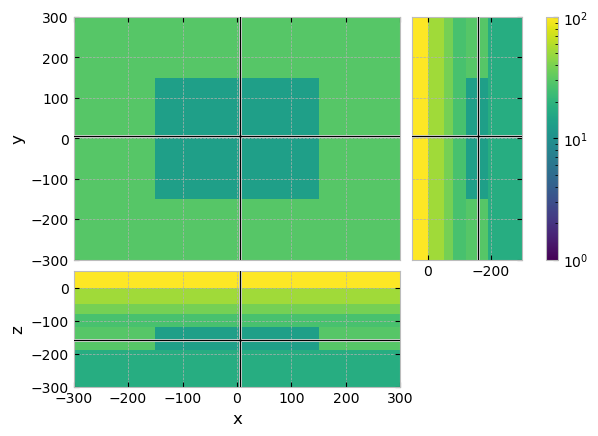

In [11]:
#QC cube location
grid.plot_3d_slicer(
    model_cube.property_x,
    pcolor_opts={'norm': LogNorm(vmin=1, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
fig = plt.gcf()

In [44]:
#insert custom hot plume values [SKIP TO NEXT STEP IF RES FILE IS ALREADY SAVED]
#Load custom plume data
comsol_plume = np.loadtxt('test_plume_1.txt', skiprows=8) #data columns: radius, depth, temperature (K)

#crop data array to limit interpolation time
plume_crop = []
for i in np.arange(len(comsol_plume[:,0])):
    if comsol_plume[i,0] < 150 and comsol_plume[i,1] > depth[4] and comsol_plume[i,1] < depth[3]:
        plume_crop.append(comsol_plume[i])

#interpolate temperature values and insert into 1d custom plume array
#To prevent edge effects, we assume that the min. temperature in the custom plume array is the original temperature of the aquifer before injection
rho_cold = resistivities_base[4]
T_cold = min(np.array(plume_crop)[:,2])
res3 = res2
for ix in np.arange(ix_min, ix_max):
    for iy in np.arange(iy_min, iy_max):
        for iz in np.arange(iz_min, iz_max):
            loc = [grid.cell_centers_x[ix], grid.cell_centers_y[iy], grid.cell_centers_z[iz]] #select a cell coordinate from our grid
            radius = np.sqrt(loc[0]**2+loc[1]**2)
            loc2d = np.array([radius, loc[2]]) #flatten to 2d coordinates
            T_hot = plume_crop[interpolate2d(loc2d, plume_crop)][2] #find temperature value of COMSOL data point closest to this cell
            res3[ix, iy, iz] = rho_cold/(1+0.025*(T_hot-T_cold)) #translate to resistivity

#Save as new file in flattened form
np.savetxt('test_plume_1_interpolated.txt', res3.ravel('F'))

## Load desired plume file

Possible plumes to use:
- 'test_plume_1_interpolated.txt': a small plume that reflects ... day injection in the default aquifer used by Gao et al.
- 'test_plume_2_interpolated.txt': a large plume that reflects ... day injection in the default aquifer used by Gao et al.

In [12]:
#load existing custom plume resistivities
res_plume = np.loadtxt('test_plume_2_interpolated.txt')
print(np.shape(res_plume))

model_plume = emg3d.Model(grid, property_x=res_plume, mapping='Resistivity')

(983040,)


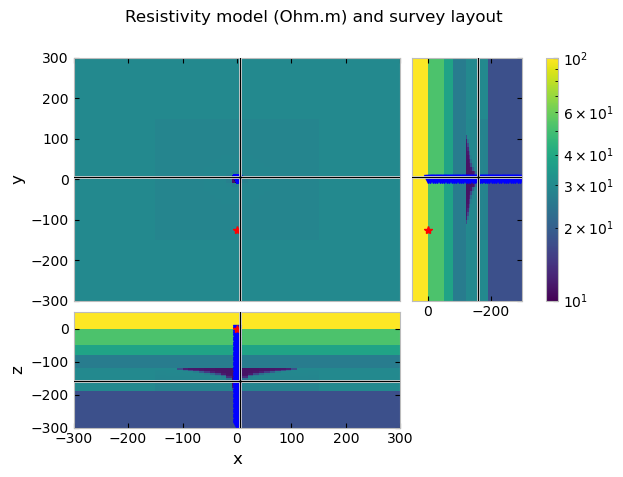

In [13]:
# Plot/QC the model with the 3D target
grid.plot_3d_slicer(
    model_plume.property_x,
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    xlim=[-300, 300],
    ylim=[-300, 300],
    zlim=[-300, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
rec_coords = receivers
src_coords = source
axs[1].plot(rec_coords[0], rec_coords[1], 'bv')
axs[2].plot(rec_coords[0], rec_coords[2], 'bv')
axs[3].plot(rec_coords[2], rec_coords[1], 'bv')
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

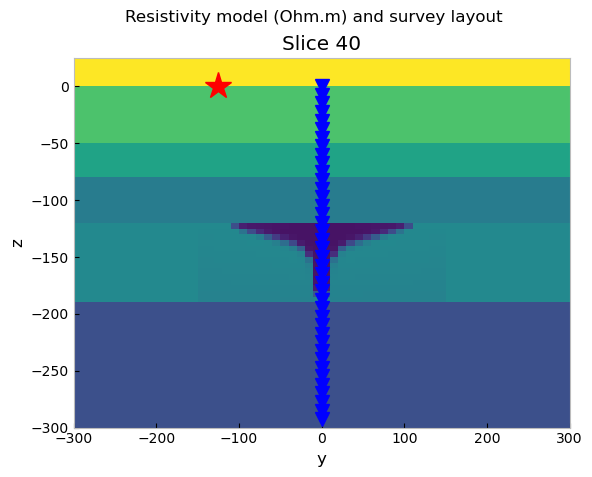

In [14]:
#Focus on the y,z plane
grid.plot_slice(
    model_plume.property_x,
    normal = 'X',
    pcolor_opts={'norm': LogNorm(vmin=10, vmax=100)},
    range_x=[-300, 300],
    range_y=[-300, 25],
#    slice_loc=0
)
fig = plt.gcf()
fig.suptitle('Resistivity model (Ohm.m) and survey layout')
axs = fig.get_children()
axs[1].plot(rec_coords[1], rec_coords[2], 'bv', markersize = 10)
axs[1].plot(src_coords[1], src_coords[2], 'r*', markersize = 20)
axs[1].grid(False)

## Simulate fields

### Generate the source field with a certain frequency

In [15]:
#
sfield = emg3d.fields.get_source_field(grid, source=source, frequency=frequency)

### Call **emg3d** to solve for the electric field components

In [16]:
# Layered base
efield3D_lay = emg3d.solve(model_base, sfield, verb=2)
# 3D target
efield3D_target = emg3d.solve(model_plume, sfield, verb=2)

:: emg3d :: 1.9e-06; 4(27); 0:03:49; CONVERGED
:: emg3d :: 1.7e-06; 4(27); 0:03:51; CONVERGED


### Extract the receiver responses

In [17]:
# Layered base
resp_E_base_3D = efield3D_lay.get_receiver(receivers, 'linear')
# 3D target
resp_E_target_3D = efield3D_target.get_receiver(receivers, 'linear')

## Plot results

### Plot your results along the receiver line

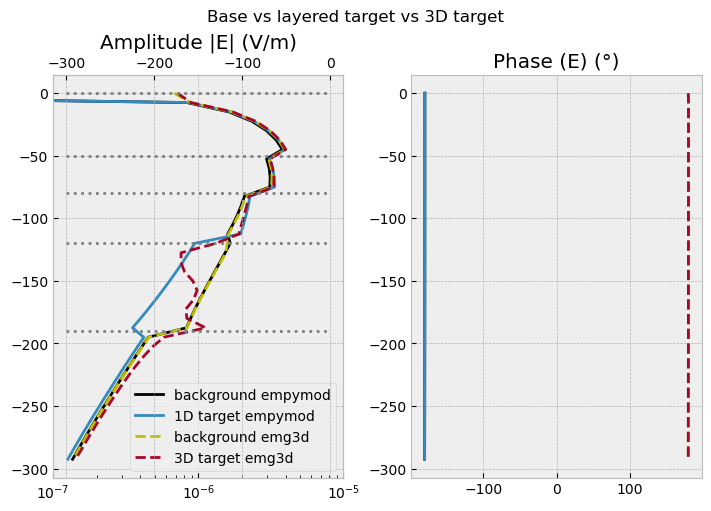

In [18]:
# Plot it
fig3, (ax31, ax32) = plt.subplots(1, 2, figsize=(7, 5), constrained_layout=True)

fig3.suptitle("Base vs layered target vs 3D target")

ax31.set_title('Amplitude |E| (V/m)')
ax31.plot(resp_E_base.amp(), -offsets, 'k', label='background empymod')
ax31.plot(resp_E_target.amp(), -offsets, 'C0-', label='1D target empymod')
ax31.plot(resp_E_base_3D.amp(), -offsets, 'y--', label='background emg3d') # scale your emg3d amplitues by the source length
ax31.plot(resp_E_target_3D.amp(), -offsets, 'C1--', label='3D target emg3d') # scale your emg3d amplitues by the source length
ax31.set_xscale('log')
ax31.set_xlim([1e-7, 1e-5])
ax31.legend()

ax32.set_title('Phase (E) (°)')
ax32.plot(resp_E_base.pha(deg=True), -offsets, 'k')
ax32.plot(resp_E_target.pha(deg=True), -offsets, 'C0-')
ax32.plot(resp_E_base_3D.pha(deg=True), -offsets, 'y--')
ax32.plot(resp_E_target_3D.pha(deg=True), -offsets, 'C1--')

ax33 = ax31.twiny()
#ax33.set_title('Model rho (Ohmm)')
#ax33.plot([75, 52.0, 52.0, 38.0, 38.0, 26.0, 26.0, 29.5, 29.5, 17.5, 17.5], [0, 0, -50, -50, -80, -80, -120, -120, -190, -190, -300], 'gray', ls='-')
ax33.hlines(depth, -300, 0, color='gray', ls=':', zorder=-1)

### Plot the **emg3d** response in the entire domain

In [19]:
# Set the field to analyze: surface: Ex; borehole: Ez
if receivers[-1] == 0:
    field, ftype = 'fx', 'Ex'
else:
    field, ftype = 'fz', 'Ez'

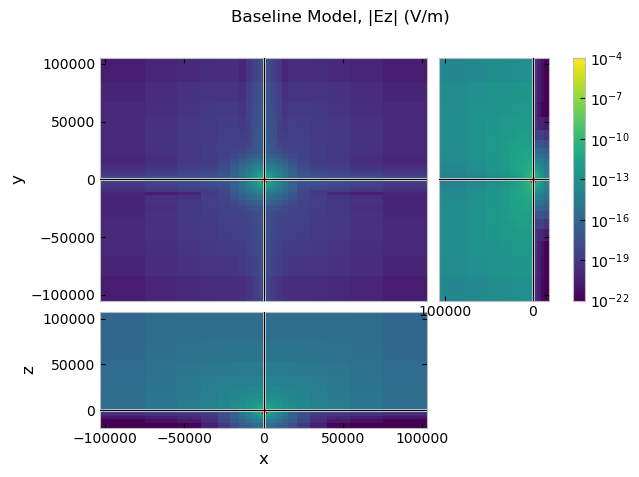

In [43]:
grid.plot_3d_slicer(
    getattr(efield3D_lay, field).ravel('F'),
    view='abs',
    v_type=ftype,
    pcolor_opts={'norm': LogNorm(vmin=1e-22, vmax=1e-4)},
    zslice = -160
)
fig = plt.gcf()
fig.suptitle(f'Baseline Model, |{ftype}| (V/m)')
axs = fig.get_children()
rec_coords = receivers
src_coords = source
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

#limits specified to be the same as for the difference

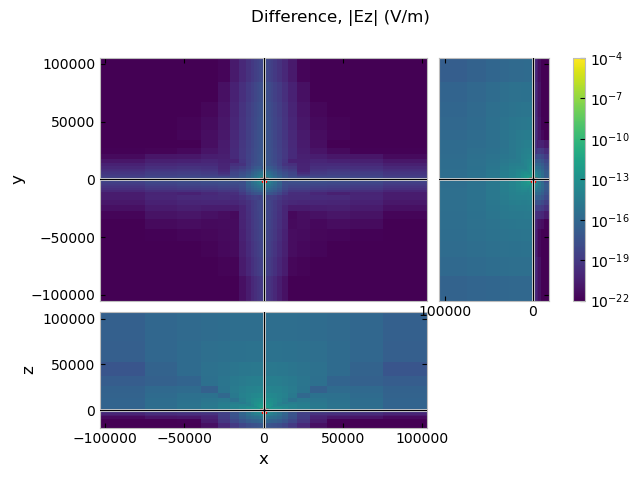

In [44]:
difference = getattr(efield3D_target, field).ravel('F')-getattr(efield3D_lay, field).ravel('F')

grid.plot_3d_slicer(
    difference,
    view='abs',
    v_type=ftype,
    pcolor_opts={'norm': LogNorm(vmin=1e-22, vmax=1e-4)},
    zslice = -160
)
fig = plt.gcf()
fig.suptitle(f'Difference, |{ftype}| (V/m)')
axs = fig.get_children()
rec_coords = receivers
src_coords = source
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

### Plot the **emg3d** response in the inner domain

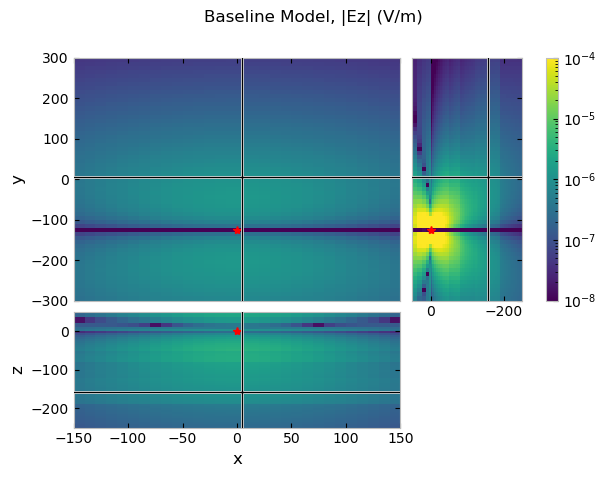

In [21]:
grid.plot_3d_slicer(
    getattr(efield3D_lay, field).ravel('F'),
    view='abs',
    v_type=ftype,
    pcolor_opts={'norm': LogNorm(vmin=1e-8, vmax=1e-4)},
    xlim=[-150, 150],
    ylim=[-300, 300],
    zlim=[-250, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle(f'Baseline Model, |{ftype}| (V/m)')
axs = fig.get_children()
rec_coords = receivers
src_coords = source
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

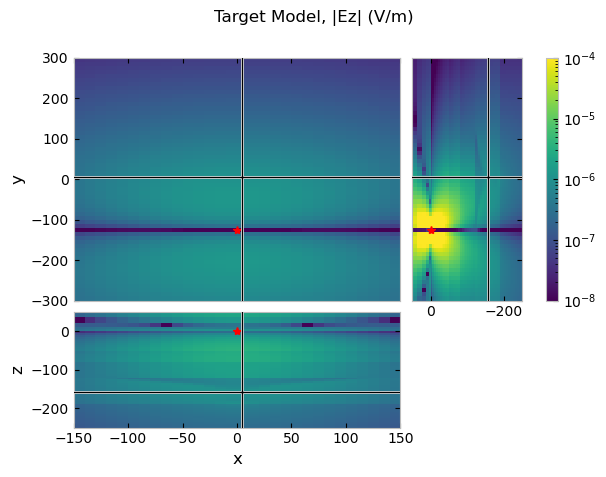

In [26]:
grid.plot_3d_slicer(
    getattr(efield3D_target, field).ravel('F'),
    view='abs',
    v_type=ftype,
    pcolor_opts={'norm': LogNorm(vmin=1e-8, vmax=1e-4)},
    xlim=[-150, 150],
    ylim=[-300, 300],
    zlim=[-250, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle(f'Target Model, |{ftype}| (V/m)')
axs = fig.get_children()
rec_coords = receivers
src_coords = source
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

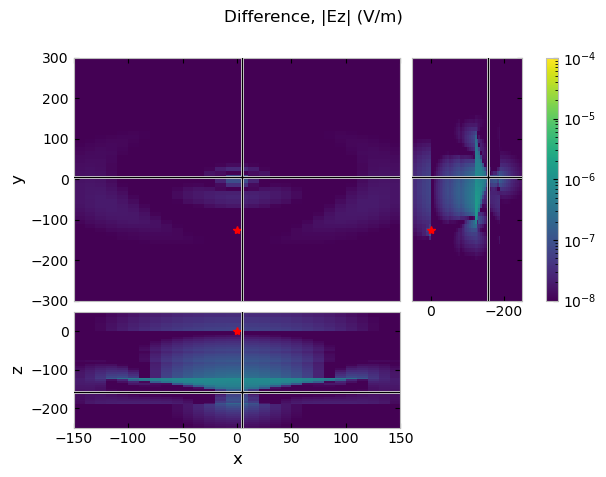

In [30]:
difference = getattr(efield3D_target, field).ravel('F')-getattr(efield3D_lay, field).ravel('F')

grid.plot_3d_slicer(
    difference,
    view='abs',
    v_type=ftype,
    pcolor_opts={'norm': LogNorm(vmin=1e-8, vmax=1e-4)},
    xlim=[-150, 150],
    ylim=[-300, 300],
    zlim=[-250, 50],
    zslice=-160,
)
# Plot survey in figure above
fig = plt.gcf()
fig.suptitle(f'Difference, |{ftype}| (V/m)')
axs = fig.get_children()
rec_coords = receivers
src_coords = source
axs[1].plot(src_coords[0], src_coords[1], 'r*')
axs[2].plot(src_coords[0], src_coords[2], 'r*')
axs[3].plot(src_coords[2], src_coords[1], 'r*')
axs[1].grid(False)
axs[2].grid(False)
axs[3].grid(False)

# REVISING STOPPED HERE

### New plots to compare against Empymod

To compare with empymod, we crop the field values to the inner domain by finding the boundary indeces. 

Note: we can only use the inner domain where no cell stretching is taking place: y = [-300, 300], z = [-250, -5] & cell width is constant

In [149]:
# Find the boundary indeces

#Select a cube for inserting a custom hot plume
grid_center_i = int((grid.n_cells+grid.shape_cells[0]*grid.shape_cells[1]+ grid.shape_cells[2])/2)
grid_center =  grid.cell_centers[grid_center_i]
iz_displacement = int((-250-grid_center[2])/5)

iy_steps = int(150/10)
iz_steps = int((depth[3]-depth[4])/5)
iy_min = int(grid.shape_cells[1]/2)-30
iy_max = int(grid.shape_cells[1]/2)+30
iz_min = int(grid.shape_cells[2]/2)+iz_displacement
iz_max = int(grid.shape_cells[2]/2)+iz_displacement+49

#QC the bounds
print('x position: ', grid.nodes_x[40])
print('y_bounds: ', grid.nodes_y[iy_min], ' , ', grid.nodes_y[iy_max])
print('z_bounds: ', grid.cell_centers_z[iz_min], ' , ', grid.cell_centers_z[iz_max])

x position:  -1.759303813742008e-11
y_bounds:  -299.99999999999443  ,  300.00000000000557
z_bounds:  -247.50000000000028  ,  -2.500000000000284


6.4
4.8


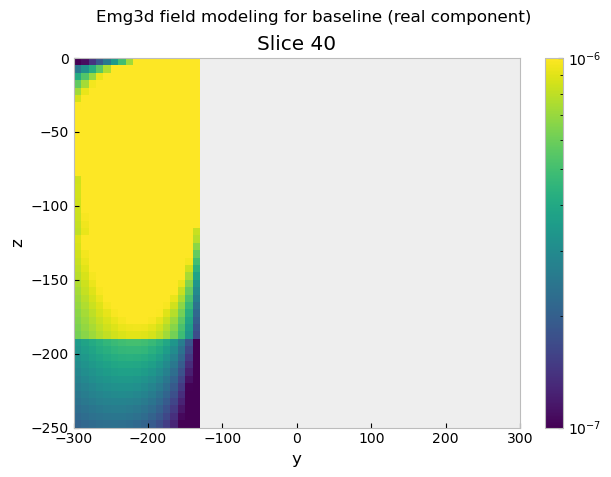

In [193]:
#Focus on the y,z plane

f0 = grid.plot_slice(
    efield3D_lay.fz.ravel('F'),
    view='real',
    v_type='Ez',
    normal = 'X',
    pcolor_opts={'cmap': 'viridis', 'norm': LogNorm(vmin=1e-7, vmax=1e-6)},
    range_x=[-300, 300],
    range_y=[-250, 0],
#    slice_loc=0
)
fig = plt.gcf()
fig.suptitle('Emg3d field modeling for baseline (real component)')
axs = fig.get_children()
axs[1].grid(False)
print(fig.get_figwidth())
print(fig.get_figheight())
fig.colorbar(f0[0], ax=axs[1], fraction=0.05, location='right')

In [156]:
# Crop Ez field array
data_base = efield3D_lay.fz[40, iy_min:iy_max+1, iz_min:iz_max+1]
data_base = np.flip(np.transpose(data), axis=0)

data_tar = efield3D_target.fz[40, iy_min:iy_max+1, iz_min:iz_max+1]
#data_tar = np.flip(np.transpose(data_tar), axis=0)

#data_diff = np.abs(data_base-data_tar)

print(np.ravel(data_base)[:5])

[7.36802042e-08-7.21258206e-11j 9.46888384e-08-8.10490372e-11j
 1.23077663e-07-9.15989345e-11j 1.62133136e-07-1.04186977e-10j
 2.16958889e-07-1.19344305e-10j]


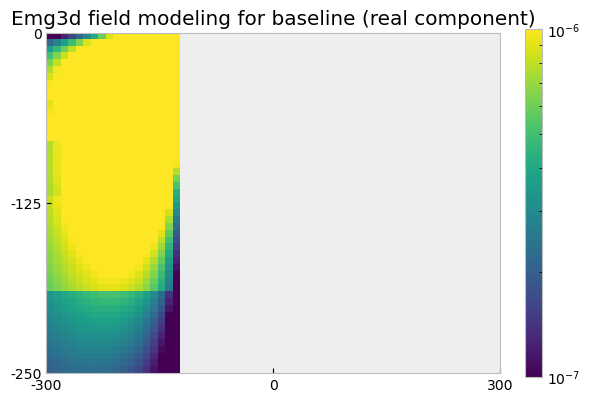

In [202]:
# Plot Emg3d response
fig, ax = plt.subplots()
plt.imshow(np.real(data_base), extent = [0, 6.4, 0, 4.8], norm='log', vmin = 1e-7, vmax = 1e-6)
ax.set_title('Emg3d field modeling for baseline (real component)')
#ax.set_xlabel('Offset (km)')
#ax.set_ylabel('Depth (1e2 m)')
plt.colorbar(location='right', fraction=0.035)
plt.xticks([0, 3.2, 6.4], [-300, 0, 300])
plt.yticks([0, 2.4, 4.8], [-250, -125, 0])
plt.grid(False)
plt.show()

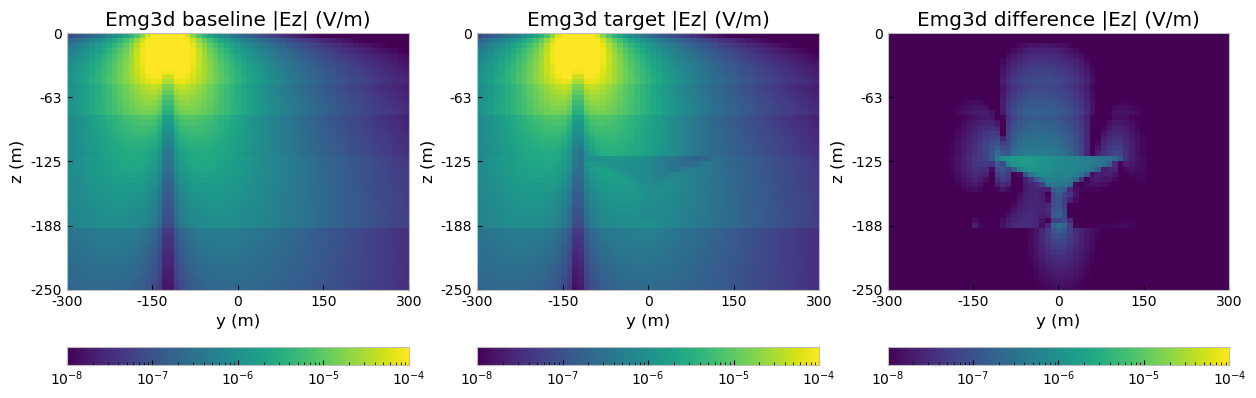

In [119]:
# Plot the Emg3d field modeling for the baseline in 2d using regular plotting functions
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(15,5))

ax1_plot = ax1.imshow(data_base, extent = [0, 6.4, 0, 4.8], norm='log', vmin = 1e-8, vmax = 1e-4)
ax1.set_title('Emg3d baseline |Ez| (V/m)')
ax1.set_xlabel('y (m)')
ax1.set_ylabel('z (m)')
plt.colorbar(ax1_plot, location='bottom')
ax1.set_xticks([0, 1.6, 3.2, 4.8, 6.4], [-300, -150, 0, 150, 300])
ax1.set_yticks([0, 1.2, 2.4, 3.6, 4.8], [-250, -188, -125, -63, 0])
ax1.grid(False)

ax2_plot = ax2.imshow(data_tar, extent = [0, 6.4, 0, 4.8], norm='log', vmin = 1e-8, vmax = 1e-4)
ax2.set_title('Emg3d target |Ez| (V/m)')
ax2.set_xlabel('y (m)')
ax2.set_ylabel('z (m)')
plt.colorbar(ax2_plot, location='bottom')
ax2.set_xticks([0, 1.6, 3.2, 4.8, 6.4], [-300, -150, 0, 150, 300])
ax2.set_yticks([0, 1.2, 2.4, 3.6, 4.8], [-250, -188, -125, -63, 0])
ax2.grid(False)

ax3_plot = ax3.imshow(data_diff, extent = [0, 6.4, 0, 4.8], norm='log', vmin = 1e-8, vmax = 1e-4)
ax3.set_title('Emg3d difference |Ez| (V/m)')
ax3.set_xlabel('y (m)')
ax3.set_ylabel('z (m)')
plt.colorbar(ax3_plot, location='bottom')
ax3.set_xticks([0, 1.6, 3.2, 4.8, 6.4], [-300, -150, 0, 150, 300])
ax3.set_yticks([0, 1.2, 2.4, 3.6, 4.8], [-250, -188, -125, -63, 0])
ax3.grid(False)


We now want to find the empymod response in the same domain and calculate the difference

In [86]:
# Find the empymod response

# Receiver depths
rcv_depths = np.arange(2.5, 252.5,5)
# Receiver offsets
offsets = np.arange(-300,310,10)

empymod_Ez_response = np.zeros((len(rcv_depths), len(offsets)))

for i in np.arange(len(rcv_depths)):
    # z-directed dipole receiver-array: x, y, z, azimuth, dip
    emp_receivers = [[0]*len(offsets), offsets, -rcv_depths[i], 0, 90.0]
    efield = empymod.bipole(
            src=source,
            rec=emp_receivers,
            depth=depth,
            res=resistivities_base,
            freqtime=frequency,
            verb=0,
    )
    empymod_Ez_response[i,:] = efield.amp()


In [88]:
# Check that array shapes are matching

print(np.shape(empymod_Ez_response))
print(np.shape(data_base))

(50, 61)
(50, 61)


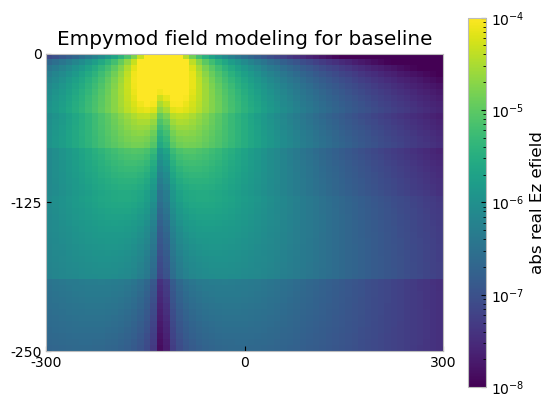

In [140]:
# Plot Empymod response
fig, ax = plt.subplots()
plt.imshow(empymod_Ez_response, extent = [0, 6.4, 0, 4.8], norm='log', vmin = 1e-8, vmax = 1e-4)
ax.set_title('Empymod field modeling for baseline')
#ax.set_xlabel('Offset (km)')
#ax.set_ylabel('Depth (1e2 m)')
plt.colorbar(location='right', label = 'abs real Ez efield')
plt.xticks([0, 3.2, 6.4], [-300, 0, 300])
plt.yticks([0, 2.4, 4.8], [-250, -125, 0])
plt.grid(False)
plt.show()

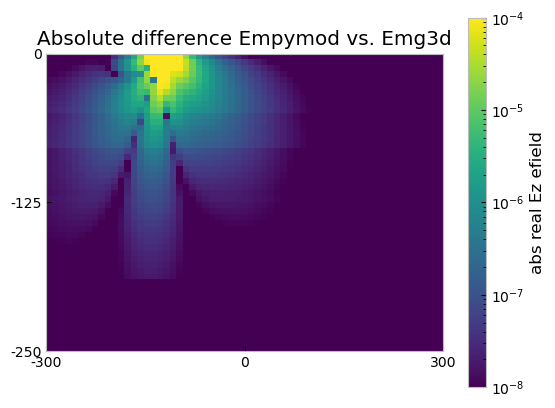

In [311]:
#plot absolute difference

fig, ax = plt.subplots()
plt.imshow(abs(empymod_Ez_response-data3), extent = [0, 6.4, 0, 4.8], norm='log', vmin = 1e-8, vmax = 1e-4)
ax.set_title('Absolute difference Empymod vs. Emg3d')
#ax.set_xlabel('Offset (km)')
#ax.set_ylabel('Depth (1e2 m)')
plt.colorbar(location='right', label = 'abs real Ez efield')
plt.xticks([0, 3.2, 6.4], [-300, 0, 300])
plt.yticks([0, 2.4, 4.8], [-250, -125, 0])
plt.grid(False)
plt.show()

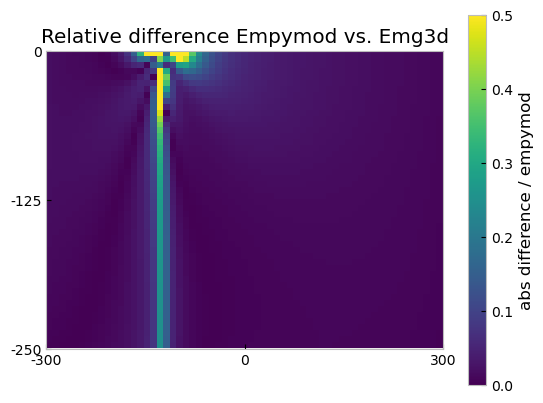

In [317]:
#plot relative difference

fig, ax = plt.subplots()
plt.imshow(abs((empymod_Ez_response-data3)/empymod_Ez_response), extent = [0, 6.4, 0, 4.8], norm='linear', vmin = 0, vmax = 0.5)
ax.set_title('Relative difference Empymod vs. Emg3d')
#ax.set_xlabel('Offset (km)')
#ax.set_ylabel('Depth (1e2 m)')
plt.colorbar(location='right', label = 'abs difference / empymod')
plt.xticks([0, 3.2, 6.4], [-300, 0, 300])
plt.yticks([0, 2.4, 4.8], [-250, -125, 0])
plt.grid(False)
plt.show()

In [347]:
# plot difference using this plot method

# Crop target field array
data4 = abs(efield3D_target.fz)[40, iy_min:iy_max+1, iz_min:iz_max+1]
data5 = np.flip(np.transpose(data4), axis=0)

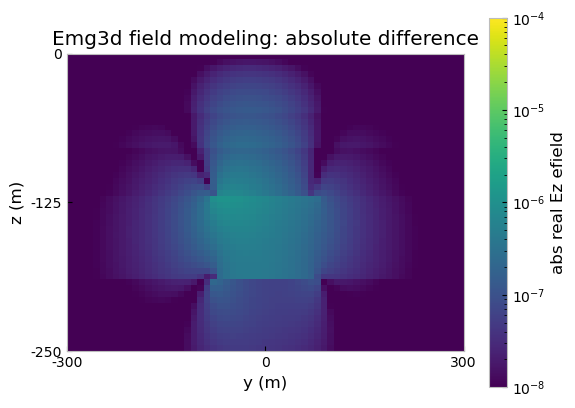

In [348]:
# Plot the Emg3d field modeling for the baseline in 2d using regular plotting functions
fig, ax = plt.subplots()
plt.imshow(abs(data3-data5), extent = [0, 6.4, 0, 4.8], norm='log', vmin = 1e-8, vmax = 1e-4)
ax.set_title('Emg3d field modeling: absolute difference')
ax.set_xlabel('y (m)')
ax.set_ylabel('z (m)')
plt.colorbar(location='right', label = 'abs real Ez efield')
plt.xticks([0, 3.2, 6.4], [-300, 0, 300])
plt.yticks([0, 2.4, 4.8], [-250, -125, 0])
plt.grid(False)
plt.show()

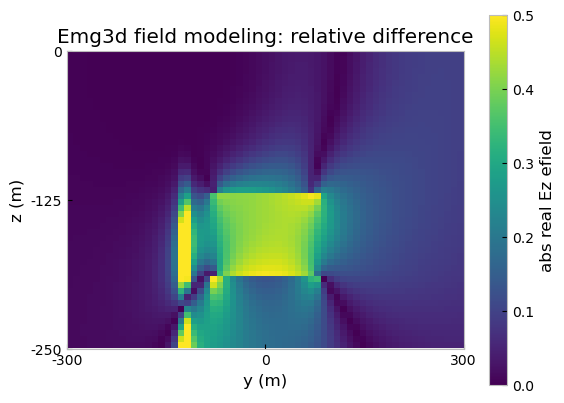

In [349]:
# Plot the Emg3d field modeling for the baseline in 2d using regular plotting functions
fig, ax = plt.subplots()
plt.imshow(abs((data3-data5)/data3), extent = [0, 6.4, 0, 4.8], norm='linear', vmin = 0, vmax = 0.5)
ax.set_title('Emg3d field modeling: relative difference')
ax.set_xlabel('y (m)')
ax.set_ylabel('z (m)')
plt.colorbar(location='right', label = 'abs real Ez efield')
plt.xticks([0, 3.2, 6.4], [-300, 0, 300])
plt.yticks([0, 2.4, 4.8], [-250, -125, 0])
plt.grid(False)
plt.show()

In [ ]:
emg3d.Report()